In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
df = pd.read_csv("dataset.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: float64(1), 

In [5]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

In [6]:
df.dtypes

id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

In [7]:
categories_cols = ["Sex", "Chest pain type", "FBS over 120", "EKG results", "Exercise angina", "Slope of ST", "Thallium"]

In [8]:
df = pd.get_dummies(df, columns = categories_cols, drop_first = True)

In [9]:
df.dtypes

id                           int64
Age                          int64
BP                           int64
Cholesterol                  int64
Max HR                       int64
ST depression              float64
Number of vessels fluro      int64
Sex_1                         bool
Chest pain type_2             bool
Chest pain type_3             bool
Chest pain type_4             bool
FBS over 120_1                bool
EKG results_1                 bool
EKG results_2                 bool
Exercise angina_1             bool
Slope of ST_2                 bool
Slope of ST_3                 bool
Thallium_6                    bool
Thallium_7                    bool
dtype: object

In [10]:
X = df.drop("id", axis = 1)
X = X.astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)  
X_pca = pca.fit_transform(X_scaled)

In [11]:
kmeans = KMeans(n_clusters = 2, random_state = 42)
labels = (X_pca[:, 0] > 0).astype(int)
df['cluster'] = labels
df.groupby('cluster').mean()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,764990.638661,52.487788,130.669783,242.333643,160.454073,0.29571,0.118426,0.560635,0.197229,0.515589,0.214621,0.068977,0.002593,0.370541,0.074940,0.192229,0.012218,0.011539,0.115770
1,765009.658643,56.076746,130.423604,248.153881,143.990500,1.20229,0.840419,0.894787,0.028857,0.077032,0.879953,0.092748,0.001677,0.623005,0.503609,0.658333,0.039621,0.023889,0.708614


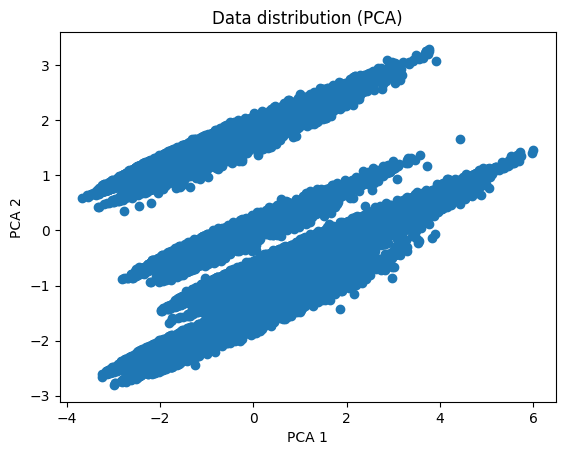

In [12]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Data distribution (PCA)')
plt.show()

In [13]:
df.groupby('cluster').mean()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,764990.638661,52.487788,130.669783,242.333643,160.454073,0.29571,0.118426,0.560635,0.197229,0.515589,0.214621,0.068977,0.002593,0.370541,0.074940,0.192229,0.012218,0.011539,0.115770
1,765009.658643,56.076746,130.423604,248.153881,143.990500,1.20229,0.840419,0.894787,0.028857,0.077032,0.879953,0.092748,0.001677,0.623005,0.503609,0.658333,0.039621,0.023889,0.708614


In [14]:
df.groupby('cluster').median()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,764980.5,52.0,130.0,239.0,162.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,765038.5,57.0,130.0,246.0,146.0,1.2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0


In [15]:
df.groupby('cluster').std()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,77930.656153,8.290711,15.216597,33.925646,14.793397,0.560630,0.392867,0.496312,0.397908,0.499759,0.410560,0.253415,0.050860,0.482951,0.263296,0.394054,0.109860,0.106798,0.319950
1,77956.235340,7.784937,14.764002,33.158039,19.793111,1.061753,0.960578,0.306829,0.167406,0.266643,0.325018,0.290081,0.040922,0.484636,0.499989,0.474271,0.195068,0.152703,0.454403


In [16]:
df.groupby('cluster').var()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,6.073187e+09,68.735890,231.544814,1150.949462,218.844604,0.314306,0.154344,0.246325,0.158331,0.249759,0.168560,0.064219,0.002587,0.233242,0.069325,0.155278,0.012069,0.011406,0.102368
1,6.077175e+09,60.605251,217.975768,1099.455528,391.767262,1.127319,0.922710,0.094144,0.028025,0.071099,0.105637,0.084147,0.001675,0.234872,0.249989,0.224933,0.038051,0.023318,0.206482


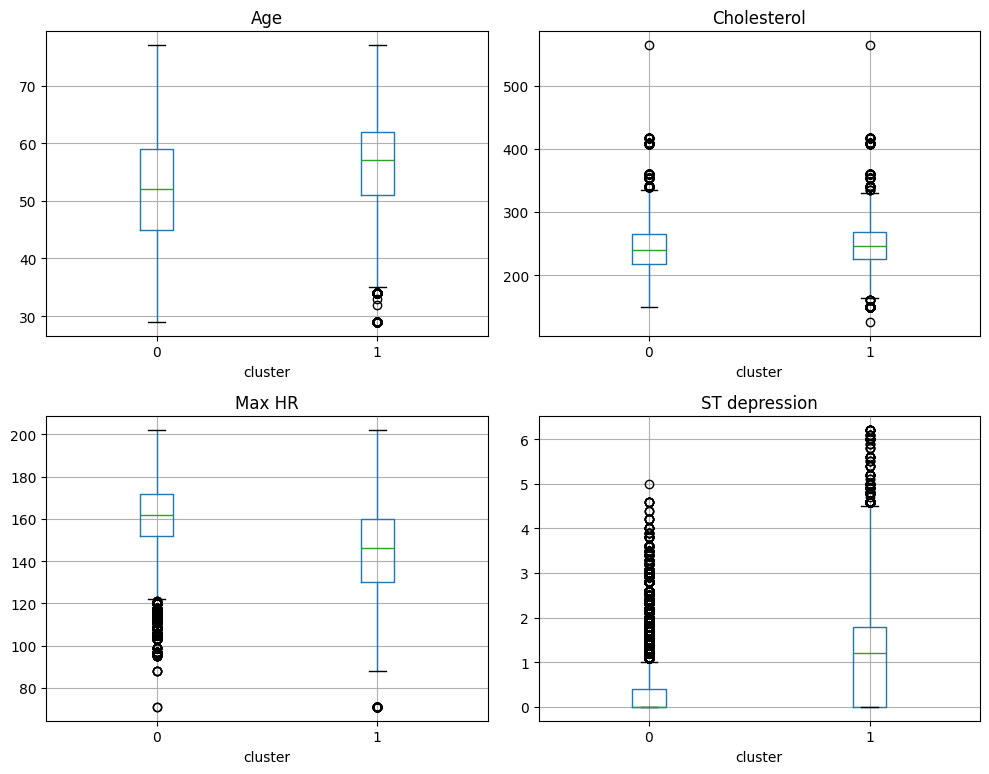

In [17]:
features = ['Age', 'Cholesterol', 'Max HR', 'ST depression']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, col in enumerate(features):
    row = i // 2
    col_idx = i % 2
    
    df.boxplot(column=col, by='cluster', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col)
    
plt.suptitle('') 
plt.tight_layout()
plt.show()

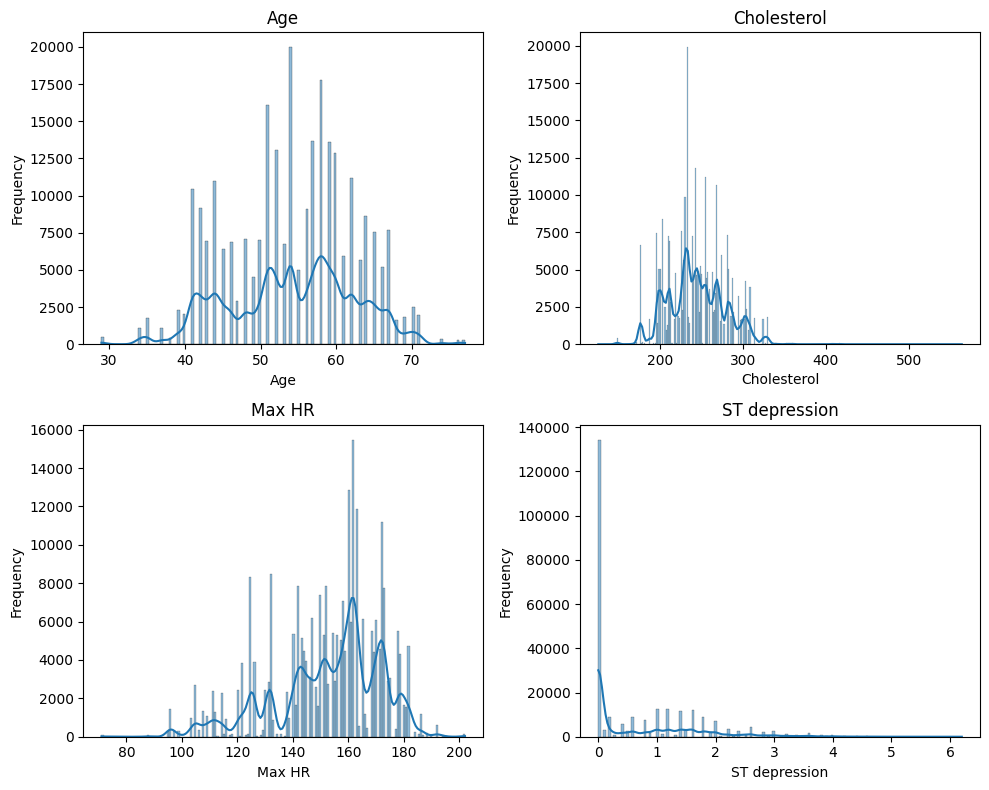

In [18]:
features = ['Age', 'Cholesterol', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, col in enumerate(features):
    row = i // 2
    col_idx = i % 2
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()

In [19]:
X = df.drop(['cluster'], axis=1)
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
print(model.score(X_test, y_test))

0.9883518518518518


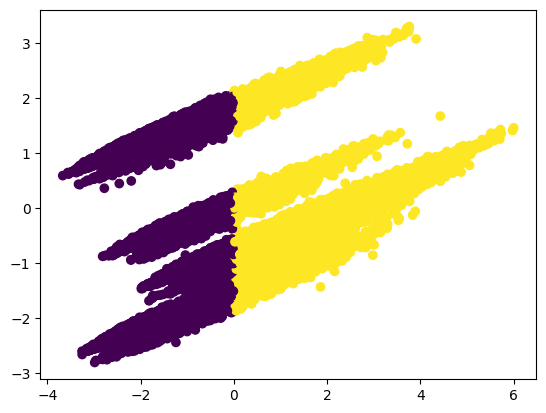

In [21]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
df['risk'] = df['cluster'].map({
    0: "Low Risk",
    1: "High Risk"
})

In [22]:
cluster_mean = df.groupby('cluster').mean(numeric_only=True)
diff = (cluster_mean.loc[1] - cluster_mean.loc[0]).sort_values()
diff

Max HR                    -16.463573
Chest pain type_3          -0.438557
BP                         -0.246178
Chest pain type_2          -0.168372
EKG results_1              -0.000916
Thallium_6                  0.012350
FBS over 120_1              0.023772
Slope of ST_3               0.027402
EKG results_2               0.252463
Sex_1                       0.334152
Exercise angina_1           0.428669
Slope of ST_2               0.466104
Thallium_7                  0.592844
Chest pain type_4           0.665332
Number of vessels fluro     0.721993
ST depression               0.906580
Age                         3.588957
Cholesterol                 5.820238
id                         19.019982
dtype: float64

In [23]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Chest pain type_4          0.212599
Thallium_7                 0.187057
Exercise angina_1          0.099088
ST depression              0.098443
Slope of ST_2              0.071175
Max HR                     0.063589
Number of vessels fluro    0.063582
Chest pain type_3          0.062427
Sex_1                      0.038144
Age                        0.025069
dtype: float64

<Axes: >

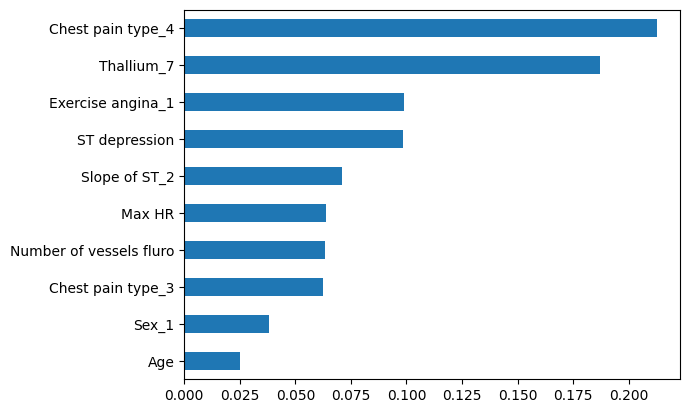

In [24]:
importance.sort_values().tail(10).plot(kind='barh')

In [25]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[28481   243]
 [  386 24890]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     28724
           1       0.99      0.98      0.99     25276

    accuracy                           0.99     54000
   macro avg       0.99      0.99      0.99     54000
weighted avg       0.99      0.99      0.99     54000



In [26]:
roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

0.9995814395950753